In [1]:
import kagglehub
import pandas as pd
import numpy as np
import ast

In [ ]:
path = kagglehub.dataset_download(
    "rounakbanik/the-movies-dataset"
)
metaDataDF = pd.read_csv(f"{path}/movies_metadata.csv")
ratingsDF = pd.read_csv(f"{path}/ratings.csv")
linksDF = pd.read_csv(f"{path}/links.csv")
creditsDF = pd.read_csv(f"{path}/credits.csv")
keywordsDF = pd.read_csv(f"{path}/keywords.csv")
links_smallDF = pd.read_csv(f"{path}/links_small.csv")
ratings_smallDF = pd.read_csv(f"{path}/ratings_small.csv")

C:\Users\Taha Riyaan\AppData\Local\Temp\ipykernel_22960\2128828587.py:4: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  metaDataDF = pd.read_csv(f"{path}/movies_metadata.csv")


# Dataset - The Movies Dataset by Rounak Banik
report by John Lopes & Taha Riyaan

## Description

"About Dataset
Context
These files contain metadata for all 45,000 movies listed in the Full MovieLens Dataset. The dataset consists of movies released on or before July 2017. Data points include cast, crew, plot keywords, budget, revenue, posters, release dates, languages, production companies, countries, TMDB vote counts and vote averages.

This dataset also has files containing 26 million ratings from 270,000 users for all 45,000 movies. Ratings are on a scale of 1-5 and have been obtained from the official GroupLens website.

Content
This dataset consists of the following files:

movies_metadata.csv: The main Movies Metadata file. Contains information on 45,000 movies featured in the Full MovieLens dataset. Features include posters, backdrops, budget, revenue, release dates, languages, production countries and companies.

keywords.csv: Contains the movie plot keywords for our MovieLens movies. Available in the form of a stringified JSON Object.

credits.csv: Consists of Cast and Crew Information for all our movies. Available in the form of a stringified JSON Object.

links.csv: The file that contains the TMDB and IMDB IDs of all the movies featured in the Full MovieLens dataset.

links_small.csv: Contains the TMDB and IMDB IDs of a small subset of 9,000 movies of the Full Dataset.

ratings_small.csv: The subset of 100,000 ratings from 700 users on 9,000 movies.

The Full MovieLens Dataset consisting of 26 million ratings and 750,000 tag applications from 270,000 users on all the 45,000 movies in this dataset can be accessed here

Acknowledgements
This dataset is an ensemble of data collected from TMDB and GroupLens.
The Movie Details, Credits and Keywords have been collected from the TMDB Open API. This product uses the TMDb API but is not endorsed or certified by TMDb. Their API also provides access to data on many additional movies, actors and actresses, crew members, and TV shows. You can try it for yourself here.

The Movie Links and Ratings have been obtained from the Official GroupLens website. The files are a part of the dataset available here



Inspiration
This dataset was assembled as part of my second Capstone Project for Springboard's Data Science Career Track. I wanted to perform an extensive EDA on Movie Data to narrate the history and the story of Cinema and use this metadata in combination with MovieLens ratings to build various types of Recommender Systems.

Both my notebooks are available as kernels with this dataset: The Story of Film and Movie Recommender Systems

Some of the things you can do with this dataset:
Predicting movie revenue and/or movie success based on a certain metric. What movies tend to get higher vote counts and vote averages on TMDB? Building Content Based and Collaborative Filtering Based Recommendation Engines."

We decided to go with this dataset because we enjoying watching movies

# Code

### Functions

In [3]:
# def check_json_columns_for_null(df, columns):
#     for col in columns:
#         if col not in df.columns:
#             continue
            
#         print(f" === Auditing Column: {col} === ")
        
#         # 1: Standard Nulls 
#         standard_nulls = df[col].isnull().sum()
        
#         # 2: Empty List Strings
#         empty_lists = (df[col] == '[]').sum()
        
#         # 3: String '[null]' 
#         string_nulls = (df[col] == '[null]').sum()
        
#         # 4: Empty strings or whitespace
#         # empty_strings = (df[col].str.strip() == '').sum() if df[col].dtype == 'object' else 0
#         empty_strings = (df[col].str.strip() == '').sum()


#         print(f"Standard NaNs Count: {standard_nulls}")
#         print(f"Empty List '[]' Count: {empty_lists}")
#         print(f"String '[null]' Count: {string_nulls}")
#         print(f"Empty Strings Count: {empty_strings}")
        
#         # 5: Check for corrupted text instead of JSON
#         try:
#             sample_val = df[col].dropna().iloc[0]
#             ast.literal_eval(sample_val)
#             print(f"Valid JSON.")
#         except Exception as e:
#             print(f"Corrupted JSON.")
        
#         print("\n")



In [4]:
def json_to_dict(x):
    if pd.isna(x) or x == '':
        return None
    try:
        return ast.literal_eval(x)
    except (ValueError, SyntaxError):
        return None

In [5]:
def json_to_list(x):
    # genres, production_companies, production_countries, spoken_languages
    
    if pd.isna(x) or x == "" or x == "[]":
        return []
    try:
        genres = ast.literal_eval(x)
        return [g['name'] for g in genres]
    except:
        return []

# df['genres'] = df['genres'].apply(extract_genres)

In [6]:

def json_to_list_cred(x):
    # creditsDF: crew, cast
    if pd.isna(x) or x == "" or x == "[]":
        return []
    try:
        return ast.literal_eval(x)
    except (ValueError, SyntaxError):
        return []

### `2. Prepare the Data`

### Basic Info

#### `movie_metadata`

In [7]:
print(' === movie_metadata Information === ')
metaDataDF.info()

print('\n === movie_metadata Shape === ')
print(metaDataDF.shape)

 === movie_metadata Information === 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45466 entries, 0 to 45465
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  45466 non-null  object 
 1   belongs_to_collection  4494 non-null   object 
 2   budget                 45466 non-null  object 
 3   genres                 45466 non-null  object 
 4   homepage               7782 non-null   object 
 5   id                     45466 non-null  object 
 6   imdb_id                45449 non-null  object 
 7   original_language      45455 non-null  object 
 8   original_title         45466 non-null  object 
 9   overview               44512 non-null  object 
 10  popularity             45461 non-null  object 
 11  poster_path            45080 non-null  object 
 12  production_companies   45463 non-null  object 
 13  production_countries   45463 non-null  object 
 14  release_date     

In [8]:
print('\n === movie_metadata Head === ')
print(metaDataDF.head(5))


 === movie_metadata Head === 
   adult                              belongs_to_collection    budget  \
0  False  {'id': 10194, 'name': 'Toy Story Collection', ...  30000000   
1  False                                                NaN  65000000   
2  False  {'id': 119050, 'name': 'Grumpy Old Men Collect...         0   
3  False                                                NaN  16000000   
4  False  {'id': 96871, 'name': 'Father of the Bride Col...         0   

                                              genres  \
0  [{'id': 16, 'name': 'Animation'}, {'id': 35, '...   
1  [{'id': 12, 'name': 'Adventure'}, {'id': 14, '...   
2  [{'id': 10749, 'name': 'Romance'}, {'id': 35, ...   
3  [{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...   
4                     [{'id': 35, 'name': 'Comedy'}]   

                               homepage     id    imdb_id original_language  \
0  http://toystory.disney.com/toy-story    862  tt0114709                en   
1                                  

In [9]:
# Columns in terms of appropriate dtype

metadata_float_cols = ['popularity', 'revenue', 'runtime', 'vote_average', 'vote_count']
metadata_int_cols = ['budget', 'id']
metadata_string_cols = [
    'homepage', 
    'imdb_id', 
    'original_language', 
    'original_title',
    'overview',
    'poster_path',
    'status',
    'tagline',
    'title'
    ]
metadata_dict_cols = ['belongs_to_collection']
metadata_list_cols = [
    'genres',
    'production_companies',
    'production_countries',
    'spoken_languages'
    ]
metadata_bool_cols = ['adult', 'video']
metadata_datetime_cols = ['release_date']

In [10]:
# Convert columns from object to appropriate dtype
import pandas as pd

metadata_converted_DF = metaDataDF.copy()

# float
for col in metadata_float_cols:
    metadata_converted_DF[col] = pd.to_numeric(metaDataDF[col], errors='coerce').astype('float64')

# int
for col in metadata_int_cols:
    metadata_converted_DF[col] = pd.to_numeric(metaDataDF[col], errors='coerce').astype('Int64')

# # string
# for col in metadata_string_cols:
#     metadata_converted_DF[col] = metaDataDF[col].astype('string')

# bool
for col in metadata_bool_cols:
    # handle cases like 'True'/'False' or 1/0
    metadata_converted_DF[col] = metaDataDF[col].map({
        True: True, False: False,
        'True': True, 'False': False,
        1: True, 0: False
    }).astype('boolean')

# date time
for col in metadata_datetime_cols:
    metadata_converted_DF[col] = pd.to_datetime(metaDataDF[col], errors='coerce')

# dict
for col in metadata_dict_cols:
    metadata_converted_DF[col] = metaDataDF[col].apply(json_to_dict)

# list
for col in metadata_list_cols:
    metadata_converted_DF[col] = metaDataDF[col].apply(json_to_list)

# verify
print(metadata_converted_DF.dtypes)

adult                           boolean
belongs_to_collection            object
budget                            Int64
genres                           object
homepage                         object
id                                Int64
imdb_id                          object
original_language                object
original_title                   object
overview                         object
popularity                      float64
poster_path                      object
production_companies             object
production_countries             object
release_date             datetime64[ns]
revenue                         float64
runtime                         float64
spoken_languages                 object
status                           object
tagline                          object
title                            object
video                           boolean
vote_average                    float64
vote_count                      float64
dtype: object


In [11]:
print('\n === movie_metadata Number of Missing Values === ')
print(metadata_converted_DF.isna().sum())


 === movie_metadata Number of Missing Values === 
adult                        3
belongs_to_collection    40972
budget                       3
genres                       0
homepage                 37684
id                           3
imdb_id                     17
original_language           11
original_title               0
overview                   954
popularity                   6
poster_path                386
production_companies         0
production_countries         0
release_date                90
revenue                      6
runtime                    263
spoken_languages             0
status                      87
tagline                  25054
title                        6
video                        6
vote_average                 6
vote_count                   6
dtype: int64


In [12]:
# clean movie_metadata
from sklearn.impute import SimpleImputer
metadata_clean = metadata_converted_DF.copy()

median_imp = SimpleImputer(missing_values=np.nan, strategy='median')

print('=== Cleaning movie_metadata -> dealing with null values ===')


# ids -> can not merge on certain tables without valid ID
# Will not recommend movie without name
# Will not recommend unreleased movie
# revenue, budget, video,  -> drop, assume movie never made it
drop = [
    'id', 
    'imdb_id', 
    'title', 
    'release_date',
    'revenue',
    'budget',
    'video'
]
print(f"== Drop following values: {', '.join(map(str, drop))} ==")
metadata_clean = metadata_clean.dropna(subset=drop)
print(f"success")

# runtime -> median run time imputation
print('== Run Median Imputation on Runtime ==')
metadata_clean['runtime'] = median_imp.fit_transform(metadata_clean[['runtime']])
print(f"success")

# popularity, vote_average, vote_count ->
# impute with 0
fill_0 = ['popularity', 'vote_average', 'vote_count']
print(f"== Impute following values with 0 {', '.join(map(str, fill_0))} ==")
metadata_clean[fill_0] = metadata_clean[fill_0].fillna(0)
print(f"success")


# production_companies, production_countries, spoken_languages 
# genres->
# impute with empty list []
fill_list = [
    'production_companies', 
    'production_countries', 
    'spoken_languages', 
    'genres', 
]
print(f"== Impute following values with [] {', '.join(map(str, fill_list))} ==")
metadata_clean[fill_list] = metadata_clean[fill_list].fillna('[]')
print(f"success")

# belongs_to_collection -> fill with "No Collection"
print('== fill belongs_to_collection with "No Collection"')
metadata_clean['belongs_to_collection'] = metadata_clean['belongs_to_collection'].fillna("No Collection")
print(f"success")


# original_language -> impute with mode, English
print(f"== Impute following values using mode: original_language ==")
metadata_clean['original_language'] = metadata_clean['original_language'].fillna(
    metadata_clean['original_language'].mode()[0]
)
print(f"success")

# status -> fill with "Unknown"
print('== fill status with "Unknown"')
metadata_clean['status'] = metadata_clean['status'].fillna("Unknown")
print(f"success")


# homepage, tagline, poster_path -> drop, no analytical value
print('== Drop rows with no analytical value for future tasks: hompage, tagline, poster_path')
metadata_clean = metadata_clean.drop(columns=['homepage', 'tagline', 'poster_path'])
print(f"success")

# overview -> fill with empty string
print('== fill overview with ""')
metadata_clean['overview'] = metadata_clean['overview'].fillna("")
print(f"success")

=== Cleaning movie_metadata -> dealing with null values ===
== Drop following values: id, imdb_id, title, release_date, revenue, budget, video ==
success
== Run Median Imputation on Runtime ==
success
== Impute following values with 0 popularity, vote_average, vote_count ==
success
== Impute following values with [] production_companies, production_countries, spoken_languages, genres ==
success
== fill belongs_to_collection with "No Collection"
success
== Impute following values using mode: original_language ==
success
== fill status with "Unknown"
success
== Drop rows with no analytical value for future tasks: hompage, tagline, poster_path
success
== fill overview with ""
success


In [13]:
print('\n === movie_metadata Number of Missing Values Check === ')
print(metadata_clean.isna().sum())


 === movie_metadata Number of Missing Values Check === 
adult                    0
belongs_to_collection    0
budget                   0
genres                   0
id                       0
imdb_id                  0
original_language        0
original_title           0
overview                 0
popularity               0
production_companies     0
production_countries     0
release_date             0
revenue                  0
runtime                  0
spoken_languages         0
status                   0
title                    0
video                    0
vote_average             0
vote_count               0
dtype: int64


#### `ratings & ratings_small`

In [14]:
print(' === ratings Information === ')
ratingsDF.info()

print('\n === ratings Shape === ')
print(ratingsDF.shape)

 === ratings Information === 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26024289 entries, 0 to 26024288
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   userId     int64  
 1   movieId    int64  
 2   rating     float64
 3   timestamp  int64  
dtypes: float64(1), int64(3)
memory usage: 794.2 MB

 === ratings Shape === 
(26024289, 4)


In [15]:
print(' === ratings_small Information === ')
ratings_smallDF.info()

print('\n === ratings_small Shape === ')
print(ratings_smallDF.shape)

 === ratings_small Information === 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100004 entries, 0 to 100003
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100004 non-null  int64  
 1   movieId    100004 non-null  int64  
 2   rating     100004 non-null  float64
 3   timestamp  100004 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB

 === ratings_small Shape === 
(100004, 4)


In [16]:
print('\n === ratings Head === ')
print(ratingsDF.head(5))


 === ratings Head === 
   userId  movieId  rating   timestamp
0       1      110     1.0  1425941529
1       1      147     4.5  1425942435
2       1      858     5.0  1425941523
3       1     1221     5.0  1425941546
4       1     1246     5.0  1425941556


In [17]:
print('\n === ratings_small Head === ')
print(ratings_smallDF.head(5))


 === ratings_small Head === 
   userId  movieId  rating   timestamp
0       1       31     2.5  1260759144
1       1     1029     3.0  1260759179
2       1     1061     3.0  1260759182
3       1     1129     2.0  1260759185
4       1     1172     4.0  1260759205


In [18]:
# Columns in terms of appropriate dtype

ratings_float_cols = ['rating']
ratings_int_cols = ['userId', 'movieId']


In [19]:
# Convert columns from object to appropriate dtype
import pandas as pd

ratings_converted_DF = ratingsDF.copy()
ratings_small_converted_DF = ratings_smallDF.copy()


# float
for col in ratings_float_cols:
    ratings_converted_DF[col] = pd.to_numeric(ratingsDF[col], errors='coerce').astype('float64')
    ratings_small_converted_DF[col] = pd.to_numeric(ratings_smallDF[col], errors='coerce').astype('float64')


# int
for col in ratings_int_cols:
    ratings_converted_DF[col] = pd.to_numeric(ratingsDF[col], errors='coerce').astype('Int64')
    ratings_small_converted_DF[col] = pd.to_numeric(ratings_smallDF[col], errors='coerce').astype('Int64')

print("=== ratings data types ===")
print(ratings_converted_DF.dtypes)

print("=== ratings_small data types ===")
print(ratings_small_converted_DF.dtypes)


=== ratings data types ===
userId         Int64
movieId        Int64
rating       float64
timestamp      int64
dtype: object
=== ratings_small data types ===
userId         Int64
movieId        Int64
rating       float64
timestamp      int64
dtype: object


In [20]:
print('\n === ratings_converted Number of Missing Values === ')
print(ratings_converted_DF.isna().sum())

print('\n === ratings_small Number of Missing Values === ')
print(ratings_small_converted_DF.isna().sum())


 === ratings_converted Number of Missing Values === 
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

 === ratings_small Number of Missing Values === 
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64


In [21]:
# clean ratings

# run filter to conly keep rows where movieId exists in metadata_clean['id']
print('Dropping rows with no movieId that matches an id in metadata_clean')
ratings_clean = ratings_converted_DF[ratings_converted_DF['movieId'].isin(metadata_clean['id'])]

print(f"Ratings remaining: {len(ratings_clean)}")

# run filter to conly keep rows where movieId exists in metadata_clean['id']
print('Dropping rows in ratings_small with no movieId that matches an id in metadata_clean')
ratings_small_clean = ratings_small_converted_DF[ratings_small_converted_DF['movieId'].isin(metadata_clean['id'])]

print(f"Ratings remaining: {len(ratings_small_clean)}")


Dropping rows with no movieId that matches an id in metadata_clean


Ratings remaining: 11429489
Dropping rows in ratings_small with no movieId that matches an id in metadata_clean
Ratings remaining: 44960


In [22]:
print('\n === ratings Number of Missing Values Check === ')
print(ratings_clean.isna().sum())

print('\n === ratings_small Number of Missing Values Check === ')
print(ratings_small_clean.isna().sum())


 === ratings Number of Missing Values Check === 
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

 === ratings_small Number of Missing Values Check === 
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64


#### `links & links_small`

In [23]:
print('\n === links Head === ')
print(linksDF.head(5))


 === links Head === 
   movieId  imdbId   tmdbId
0        1  114709    862.0
1        2  113497   8844.0
2        3  113228  15602.0
3        4  114885  31357.0
4        5  113041  11862.0


In [24]:
print('\n === links_small Head === ')
print(links_smallDF.head(5))


 === links_small Head === 
   movieId  imdbId   tmdbId
0        1  114709    862.0
1        2  113497   8844.0
2        3  113228  15602.0
3        4  114885  31357.0
4        5  113041  11862.0


In [25]:
# Columns in terms of appropriate dtype

links_int_cols = ['movieId', 'imdbId', 'tmdbId']


In [26]:
# Convert columns from object to appropriate dtype
import pandas as pd

links_converted_DF = linksDF.copy()
links_small_converted_DF = links_smallDF.copy()

# int
for col in links_int_cols:
    links_converted_DF[col] = pd.to_numeric(linksDF[col], errors='coerce').astype('Int64')
    links_small_converted_DF[col] = pd.to_numeric(links_smallDF[col], errors='coerce').astype('Int64')

print("=== ratings data types ===")
print(ratings_converted_DF.dtypes)

print("=== ratings_small data types ===")
print(ratings_small_converted_DF.dtypes)


=== ratings data types ===
userId         Int64
movieId        Int64
rating       float64
timestamp      int64
dtype: object
=== ratings_small data types ===
userId         Int64
movieId        Int64
rating       float64
timestamp      int64
dtype: object


In [27]:
print('\n === links_converted Number of Missing Values === ')
print(links_converted_DF.isna().sum())

print('\n === links_small Number of Missing Values === ')
print(links_small_converted_DF.isna().sum())


 === links_converted Number of Missing Values === 
movieId      0
imdbId       0
tmdbId     219
dtype: int64

 === links_small Number of Missing Values === 
movieId     0
imdbId      0
tmdbId     13
dtype: int64


In [28]:
# clean links

# run filter to only keep rows where movieId exists in metadata_clean['id']
print('Dropping rows with no movieId that matches an id in metadata_clean')
links_clean = links_converted_DF[links_converted_DF['movieId'].isin(metadata_clean['id'])]

print(f"links remaining: {len(links_clean)}")

Dropping rows with no movieId that matches an id in metadata_clean
links remaining: 7626


#### `Credits`


In [29]:
print(' === credits Information === ')
creditsDF.info()

print('\n === credits Shape === ')
print(creditsDF.shape)

 === credits Information === 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45476 entries, 0 to 45475
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   cast    45476 non-null  object
 1   crew    45476 non-null  object
 2   id      45476 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 1.0+ MB

 === credits Shape === 
(45476, 3)


In [30]:
print('\n === credits Head === ')
print(creditsDF.head(5))


 === credits Head === 
                                                cast  \
0  [{'cast_id': 14, 'character': 'Woody (voice)',...   
1  [{'cast_id': 1, 'character': 'Alan Parrish', '...   
2  [{'cast_id': 2, 'character': 'Max Goldman', 'c...   
3  [{'cast_id': 1, 'character': "Savannah 'Vannah...   
4  [{'cast_id': 1, 'character': 'George Banks', '...   

                                                crew     id  
0  [{'credit_id': '52fe4284c3a36847f8024f49', 'de...    862  
1  [{'credit_id': '52fe44bfc3a36847f80a7cd1', 'de...   8844  
2  [{'credit_id': '52fe466a9251416c75077a89', 'de...  15602  
3  [{'credit_id': '52fe44779251416c91011acb', 'de...  31357  
4  [{'credit_id': '52fe44959251416c75039ed7', 'de...  11862  


In [31]:
# Columns in terms of appropriate dtype

credits_int_cols = ['id']
credits_list_cols = [
    'crew',
    'cast',
    ]


In [32]:
credits_converted_DF = creditsDF.copy()

# int
for col in credits_int_cols:
    credits_converted_DF[col] = pd.to_numeric(creditsDF[col], errors='coerce').astype('Int64')

# list
for col in credits_list_cols:
    credits_converted_DF[col] = creditsDF[col].apply(json_to_list_cred)

# verify
print(credits_converted_DF.dtypes)

cast    object
crew    object
id       Int64
dtype: object


In [33]:
print('\n === credits Number of Missing Values === ')
print(credits_converted_DF.isna().sum())


 === credits Number of Missing Values === 
cast    0
crew    0
id      0
dtype: int64


In [34]:
credits_converted_DF.head()

,cast,crew,id
0,"[{'cast_id': 14, 'character': 'Woody (voice)',...","[{'credit_id': '52fe4284c3a36847f8024f49', 'de...",862
1,"[{'cast_id': 1, 'character': 'Alan Parrish', '...","[{'credit_id': '52fe44bfc3a36847f80a7cd1', 'de...",8844
2,"[{'cast_id': 2, 'character': 'Max Goldman', 'c...","[{'credit_id': '52fe466a9251416c75077a89', 'de...",15602
3,"[{'cast_id': 1, 'character': 'Savannah 'Vannah...","[{'credit_id': '52fe44779251416c91011acb', 'de...",31357
4,"[{'cast_id': 1, 'character': 'George Banks', '...","[{'credit_id': '52fe44959251416c75039ed7', 'de...",11862


In [35]:
# clean credits

# run filter to only keep rows where id exists in metadata_clean['id']
print('Dropping rows with no movieId that matches an id in metadata_clean')
credits_clean = credits_converted_DF[credits_converted_DF['id'].isin(metadata_clean['id'])]

print(f"Credits remaining: {len(credits_clean)}")


Dropping rows with no movieId that matches an id in metadata_clean
Credits remaining: 45375


#### `keywords`


In [36]:
print(' === keywords Information === ')
keywordsDF.info()

print('\n === keywords Shape === ')
print(keywordsDF.shape)

 === keywords Information === 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46419 entries, 0 to 46418
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        46419 non-null  int64 
 1   keywords  46419 non-null  object
dtypes: int64(1), object(1)
memory usage: 725.4+ KB

 === keywords Shape === 
(46419, 2)


In [37]:
print('\n === keywords Head === ')
print(ratingsDF.head(5))


 === keywords Head === 
   userId  movieId  rating   timestamp
0       1      110     1.0  1425941529
1       1      147     4.5  1425942435
2       1      858     5.0  1425941523
3       1     1221     5.0  1425941546
4       1     1246     5.0  1425941556


In [38]:
# Columns in terms of appropriate dtype

keywords_int_cols = ['id']
keywords_list_cols = [
    'keywords',
    ]


In [39]:
keywords_converted_DF = keywordsDF.copy()

# int
for col in keywords_int_cols:
    keywords_converted_DF[col] = pd.to_numeric(keywordsDF[col], errors='coerce').astype('Int64')

# list
for col in keywords_list_cols:
    keywords_converted_DF[col] = keywordsDF[col].apply(json_to_list)

# verify
print(keywords_converted_DF.dtypes)

id           Int64
keywords    object
dtype: object


In [40]:
print('\n === keywords Number of Missing Values === ')
print(keywords_converted_DF.isna().sum())


 === keywords Number of Missing Values === 
id          0
keywords    0
dtype: int64


In [41]:
keywords_converted_DF.head()

,id,keywords
0,862,"[jealousy, toy, boy, friendship, friends, riva..."
1,8844,"[board game, disappearance, based on children'..."
2,15602,"[fishing, best friend, duringcreditsstinger, o..."
3,31357,"[based on novel, interracial relationship, sin..."
4,11862,"[baby, midlife crisis, confidence, aging, daug..."


In [42]:
# clean keywords

# run filter to only keep rows where id exists in metadata_clean['id']
print('Dropping rows with no movieId that matches an id in metadata_clean')
keywords_clean = keywords_converted_DF[keywords_converted_DF['id'].isin(metadata_clean['id'])]

print(f"keywords remaining: {len(keywords_clean)}")

Dropping rows with no movieId that matches an id in metadata_clean
keywords remaining: 46317


### `Dictionary Cleaning`

#### `movie_metadata`


In [43]:
def belongs_to_coll_dict(x):
    if isinstance(x, dict):
        return True, x.get('id'), x.get('name')
    return False, None, None

In [44]:
"""
Flatten the dictionaries in belongs_to_collection ->
    belongs_to_collection: contains T/F
    collection_id: contains collection id
    collection_name: contains collection name

poster_path and backdrop dropped due to lack of analytical value

"""

metadata_clean[['belongs_to_collection', 'collection_id', 'collection_name']] = \
    metadata_clean['belongs_to_collection'].apply(belongs_to_coll_dict).apply(pd.Series)

print(metadata_clean.head())

   adult  belongs_to_collection    budget                        genres  \
0  False                   True  30000000   [Animation, Comedy, Family]   
1  False                  False  65000000  [Adventure, Fantasy, Family]   
2  False                   True         0             [Romance, Comedy]   
3  False                  False  16000000      [Comedy, Drama, Romance]   
4  False                   True         0                      [Comedy]   

      id    imdb_id original_language               original_title  \
0    862  tt0114709                en                    Toy Story   
1   8844  tt0113497                en                      Jumanji   
2  15602  tt0113228                en             Grumpier Old Men   
3  31357  tt0114885                en            Waiting to Exhale   
4  11862  tt0113041                en  Father of the Bride Part II   

                                            overview  popularity  ...  \
0  Led by Woody, Andy's toys live happily in his ...   

## Study 1

subset = genres, revenue, runtime, vote_average, title

Jaccard

In [46]:
def extractGenreNames(genres):
    if pd.isna(genres):
        return set()
    if isinstance(genres, str):
        try:
            genres = ast.literal_eval(genres)
        except (ValueError, SyntaxError):
            return set()
    if isinstance(genres, list):
        return {item['name'] for item in genres if isinstance(item, dict) and 'name' in item}
    return set()

def jaccardSimilarity(a, b):
    if not a and not b:
        return 1.0
    union = a | b
    return len(a & b) / len(union) if union else 0.0

movie = "Minions"
movieName = movie.lower()

movieRow = metaDataDF[metaDataDF['title'].str.lower() == movieName]
if movieRow.empty:
    movieRow = metaDataDF[metaDataDF['original_title'].str.lower() == movieName]

movieGenres = extractGenreNames(movieRow.iloc[0]['genres']) if not movieRow.empty else set()
print(movie + " genres: " + str(movieGenres))

jaccardScores = []
for title in metaDataDF['title']:
    movieRow = metaDataDF[metaDataDF['title'] == title]
    if movieRow.empty:
        movieRow = metaDataDF[metaDataDF['original_title'] == title]
    genres = extractGenreNames(movieRow.iloc[0]['genres']) if not movieRow.empty else set()
    jaccardScores.append({
        'title': title,
        'genres': genres,
        'jaccard_similarity': jaccardSimilarity(movieGenres, genres),
    })

jaccardDF = pd.DataFrame(jaccardScores).sort_values('jaccard_similarity', ascending=False)
jaccardDF = jaccardDF[jaccardDF['title'] != movie]
jaccardDF.head(10)

Minions genres: {'Adventure', 'Family', 'Comedy', 'Animation'}


,title,genres,jaccard_similarity
8610,Asterix the Gaul,"{Adventure, Family, Comedy, Animation}",1.0
8626,Asterix and Cleopatra,"{Adventure, Family, Comedy, Animation}",1.0
43156,Smurfs: The Lost Village,"{Adventure, Comedy, Family, Animation}",1.0
608,The Aristocats,"{Comedy, Family, Adventure, Animation}",1.0
41586,Tri bogatyrya i Shamakhanskaya tsaritsa,"{Comedy, Family, Adventure, Animation}",1.0
40608,Storks,"{Adventure, Comedy, Family, Animation}",1.0
39750,VeggieTales: Tomato Sawyer & Huckleberry Larry...,"{Comedy, Family, Adventure, Animation}",1.0
39734,VeggieTales: Dave and the Giant Pickle,"{Adventure, Family, Comedy, Animation}",1.0
43294,Cars 3,"{Adventure, Family, Animation, Comedy}",1.0
39334,Ice Age: Collision Course,"{Adventure, Family, Comedy, Animation}",1.0


Manhattan

In [ ]:
movie = "Mortal Kombat"
movieName = movie.lower()

movieRow = metaDataDF[metaDataDF['title'].str.lower() == movieName]
if movieRow.empty:
    movieRow = metaDataDF[metaDataDF['original_title'].str.lower() == movieName]

movieRevenue = movieRow.iloc[0]['revenue'] if not movieRow.empty else 0.0
print(movie + " revenue: " + str(movieRevenue))

manhattanDistances = []
for i, row in metaDataDF.iterrows():
    rev = row['revenue']
    if pd.isna(rev) or pd.isna(movieRevenue):
        dist = float('inf')
    else:
        dist = abs(rev - movieRevenue)
    manhattanDistances.append({
        'title': row['title'],
        'revenue': rev,
        'manhattan_distance': dist,
    })

manhattanDF = pd.DataFrame(manhattanDistances)
manhattanDF = manhattanDF[manhattanDF['title'] != movie]
manhattanDF = manhattanDF.sort_values('manhattan_distance')
manhattanDF.head(10)

Mortal Kombat revenue: 122195920.0


,title,revenue,manhattan_distance
1885,Poltergeist,122200000.0,4080.0
14494,Invictus,122233971.0,38051.0
21604,Prisoners,122126687.0,69233.0
7011,Peter Pan,121975011.0,220909.0
1631,MouseHunt,122417389.0,221469.0
489,Executive Decision,121969216.0,226704.0
14234,Surrogates,122444772.0,248852.0
10762,Nanny McPhee,122489822.0,293902.0
31322,Magic Mike XXL,122513057.0,317137.0
5255,Spirit: Stallion of the Cimarron,122563539.0,367619.0


Euclidean

In [ ]:
movie = "Jumanji"
movieName = movie.lower()

movieRow = metaDataDF[metaDataDF['title'].str.lower() == movieName]
if movieRow.empty:
    movieRow = metaDataDF[metaDataDF['original_title'].str.lower() == movieName]

movieVoteAverage = movieRow.iloc[0]['vote_average'] if not movieRow.empty else 0.0
print(movie + " vote average: " + str(movieVoteAverage))

euclideanDistances = []
for i, row in metaDataDF.iterrows():
    rt = row['vote_average']
    if pd.isna(rt) or pd.isna(movieVoteAverage):
        dist = float('inf')
    else:
        dist = np.sqrt((rt - movieVoteAverage) ** 2)
    euclideanDistances.append({
        'title': row['title'],
        'vote_average': rt,
        'euclidean_distance': dist,
    })

euclideanDF = pd.DataFrame(euclideanDistances)
euclideanDF = euclideanDF[euclideanDF['title'] != movie]
euclideanDF = euclideanDF.sort_values('euclidean_distance')
euclideanDF.head(10)

Jumanji vote average: 6.9


,title,vote_average,euclidean_distance
40887,Validation,6.9,0.0
32352,Spirit of the Marathon,6.9,0.0
20522,"Look, Up in the Sky: The Amazing Story of Supe...",6.9,0.0
18387,The Pruitt-Igoe Myth,6.9,0.0
20609,Operation: Daybreak,6.9,0.0
39950,Love Begins,6.9,0.0
1250,A Room with a View,6.9,0.0
1245,Some Kind of Wonderful,6.9,0.0
18275,This Is Not a Film,6.9,0.0
33550,How To Change The World,6.9,0.0


In [ ]:
movie = "Avatar"
movieName = movie.lower()

movieRow = metaDataDF[metaDataDF['title'].str.lower() == movieName]
if movieRow.empty:
    movieRow = metaDataDF[metaDataDF['original_title'].str.lower() == movieName]

movieRuntime = movieRow.iloc[0]['runtime'] if not movieRow.empty else 0.0
print(movie + " runtime: " + str(movieRuntime))

euclideanDistances = []
for i, row in metaDataDF.iterrows():
    rt = row['runtime']
    if pd.isna(rt) or pd.isna(movieRuntime):
        dist = float('inf')
    else:
        dist = np.sqrt((rt - movieRuntime) ** 2)
    euclideanDistances.append({
        'title': row['title'],
        'runtime': rt,
        'euclidean_distance': dist,
    })

euclideanDF = pd.DataFrame(euclideanDistances)
euclideanDF = euclideanDF[euclideanDF['title'] != movie]
euclideanDF = euclideanDF.sort_values('euclidean_distance')
euclideanDF.head(10)

Avatar runtime: 162.0


,title,runtime,euclidean_distance
38801,Toni Erdmann,162.0,0.0
14992,Bunty Aur Babli,162.0,0.0
18451,The Disappearance of Haruhi Suzumiya,162.0,0.0
36560,Garv: Pride and Honour,162.0,0.0
33610,Times of Joy and Sorrow,162.0,0.0
29622,Sarfarosh,162.0,0.0
33434,A Tale of Two Cities,162.0,0.0
12520,Marketa Lazarová,162.0,0.0
7934,How the West Was Won,162.0,0.0
36571,Rakht,162.0,0.0


Edit Distance

In [ ]:
def levenshtein(s1, s2):
    if len(s1) < len(s2):
        return levenshtein(s2, s1)
    if len(s2) == 0:
        return len(s1)
    previousRow = list(range(len(s2) + 1))
    for i, c1 in enumerate(s1):
        currentRow = [i + 1]
        for j, c2 in enumerate(s2):
            insertions = previousRow[j + 1] + 1
            deletions = currentRow[j] + 1
            substitutions = previousRow[j] + (c1 != c2)
            currentRow.append(min(insertions, deletions, substitutions))
        previousRow = currentRow
    return previousRow[-1]

movie = "Pacific Rum"
editDistances = []
for title in metaDataDF['title']:
    dist = levenshtein(movie, str(title))
    editDistances.append({
        'title': title,
        'edit_distance': dist,
    })

editDF = pd.DataFrame(editDistances).sort_values('edit_distance')
editDF.head(10)

,title,edit_distance
21123,Pacific Rim,1
5132,Panic Room,5
26192,Sacrifice,6
38348,Sacrifice,6
18385,Sacrifice,6
40995,Pacific Banana,6
30770,Traffic Jam,6
9239,Mimic 2,7
11792,Maniac Cop,7
35942,Panic,7


## Study 2

#### KMeans `revenue, runtime, vote_average`

In [88]:
from sklearn.preprocessing import StandardScaler

metadata_kmeans = metadata_clean.copy()

metadata_kmeans = metadata_kmeans[metadata_kmeans['revenue'] > 0]

print('Scaling Revenue and Runtime values...')

scaler = StandardScaler()
scaled_rr = scaler.fit_transform(metadata_kmeans[['revenue', 'runtime']])

Scaling Revenue and Runtime values...


Use Elbow method to determine best k value between range of 2 to 10


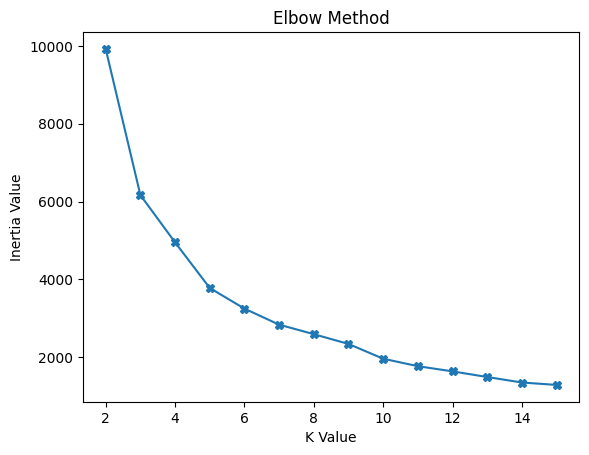

In [89]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

print(f'Use Elbow method to determine best k value between range of 2 to 10')

inerties = []
k_values = range(2, 16)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_rr)
    inerties.append(kmeans.inertia_)

plt.plot(k_values, inerties, marker='X')
plt.xlabel('K Value')
plt.ylabel('Inertia Value')
plt.title('Elbow Method')
plt.show()

In [90]:
from kneed import KneeLocator

print(f'\n\nUse KneeLocator from kneed library to determine elbow point.')
knee = KneeLocator(k_values, inerties, curve='convex', direction='decreasing')
print(f'The elbow is: {knee.elbow}')



Use KneeLocator from kneed library to determine elbow point.
The elbow is: 5


choosing test cluster values of [3, 5, 8]
Running KMeans clustering on revenue and runtime...
Running KMeans on Revenue and Runtime with K value of 3...
Plotting result with K value of 3...


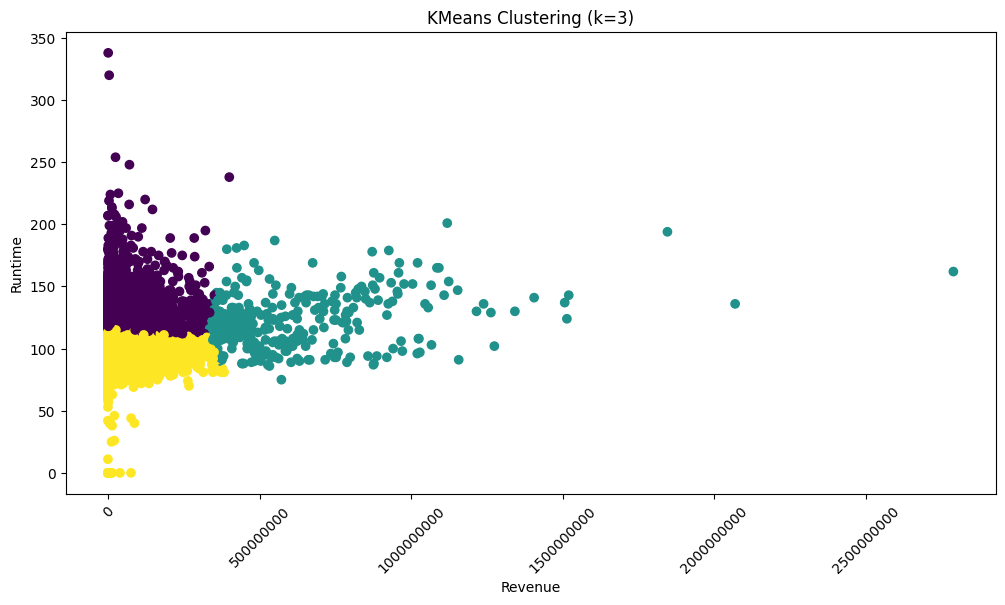

Running KMeans on Revenue and Runtime with K value of 5...
Plotting result with K value of 5...


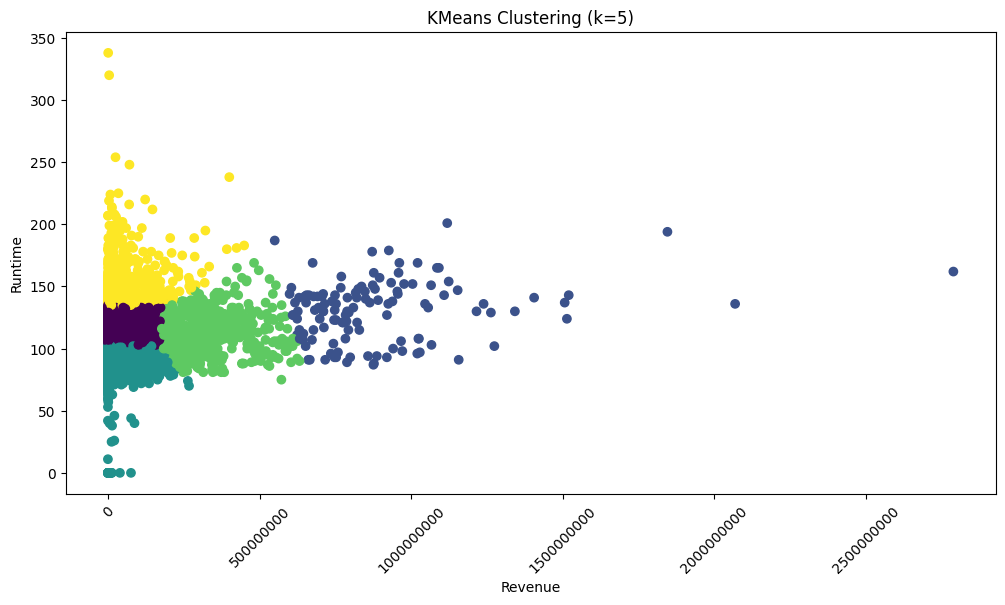

Running KMeans on Revenue and Runtime with K value of 8...
Plotting result with K value of 8...


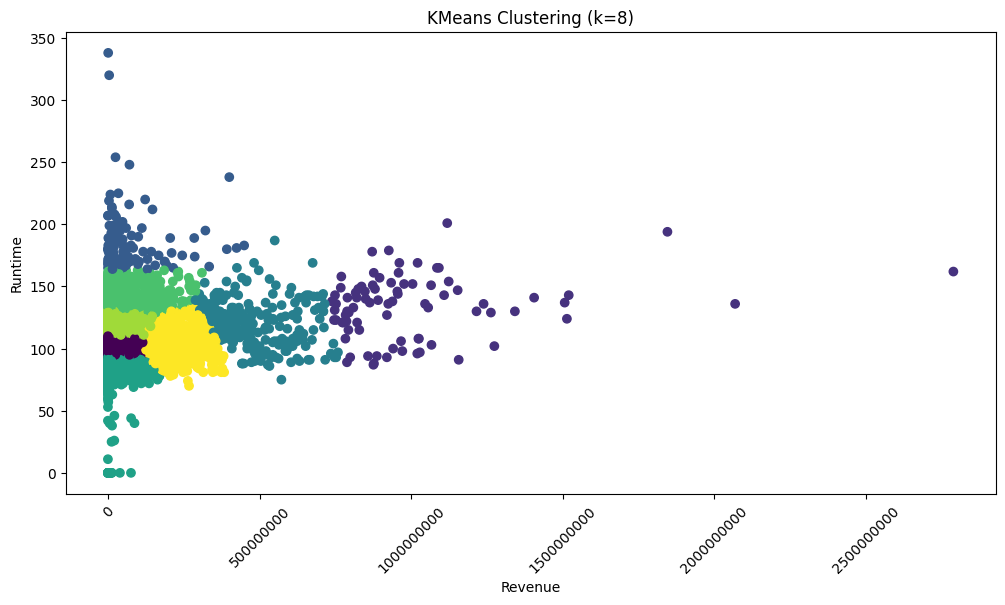

In [91]:
k_values = [3, 5, 8]
print(f'choosing test cluster values of {k_values}')

print(f'Running KMeans clustering on revenue and runtime...')
for k in k_values:
    print(f'Running KMeans on Revenue and Runtime with K value of {k}...')
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_rr)
    metadata_kmeans[f'cluster_{k}'] = kmeans.labels_

    print(f'Plotting result with K value of {k}...')
    plt.figure(figsize=(12, 6))
    plt.scatter(metadata_kmeans['revenue'], metadata_kmeans['runtime'], c = metadata_kmeans[f'cluster_{k}'])
    plt.xlabel('Revenue')
    plt.ylabel('Runtime')
    plt.title(f'KMeans Clustering (k={k})')
    plt.ticklabel_format(style='plain', axis='x')
    plt.xticks(rotation=45)
    plt.show()




Filtering outliers using by visual analysis and recalculating Kmeans and replotting...
Scaling Revenue and Runtime values...
Use Elbow method to determine best k value between range of 2 to 10


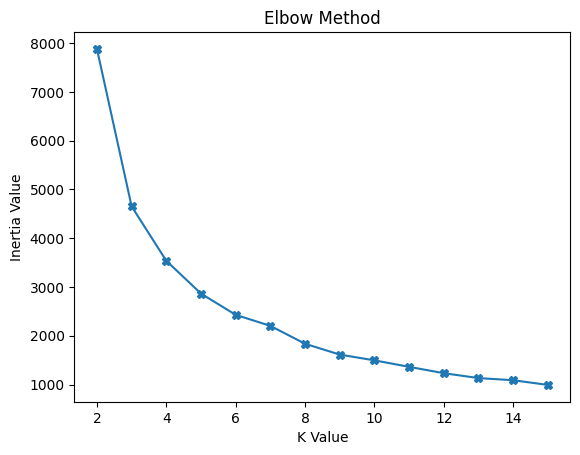



Use KneeLocator from kneed library to determine elbow point.
The elbow is: 5
choosing test cluster values of [3, 5, 8]
Running KMeans clustering on revenue and runtime...
Running KMeans on Revenue and Runtime with K value of 3...
Plotting outlier filtered result with K value of 3...


C:\Users\Taha Riyaan\AppData\Local\Temp\ipykernel_22960\1681040208.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered[f'cluster_{k}'] = kmeans.labels_


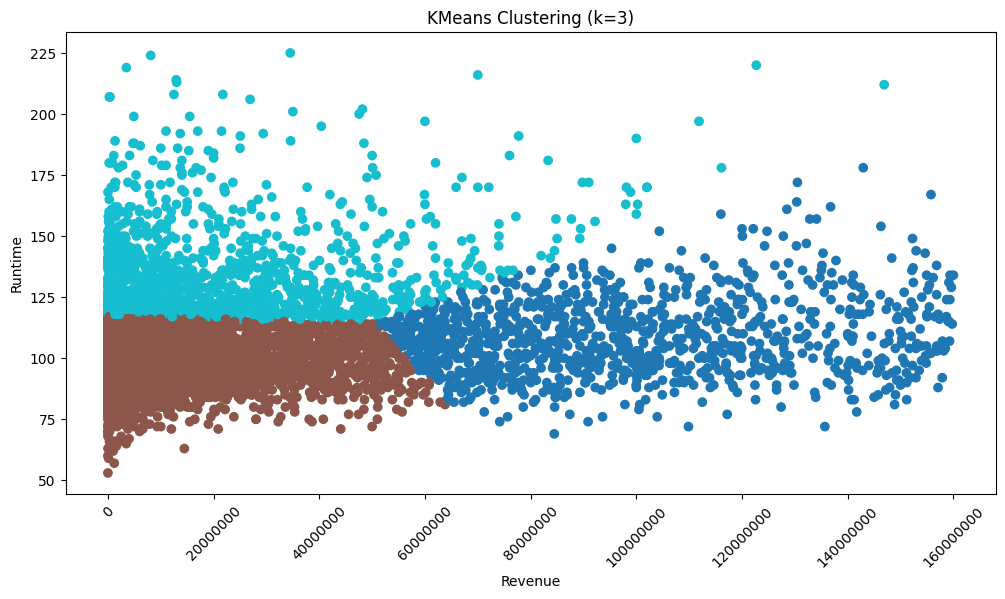

Running KMeans on Revenue and Runtime with K value of 5...
Plotting outlier filtered result with K value of 5...


C:\Users\Taha Riyaan\AppData\Local\Temp\ipykernel_22960\1681040208.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered[f'cluster_{k}'] = kmeans.labels_


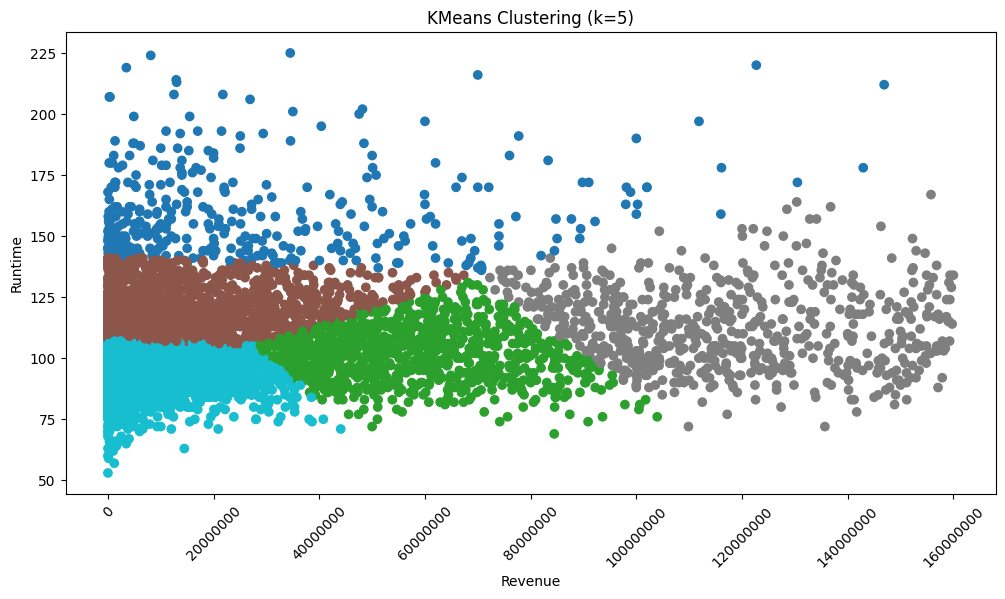

Running KMeans on Revenue and Runtime with K value of 8...
Plotting outlier filtered result with K value of 8...


C:\Users\Taha Riyaan\AppData\Local\Temp\ipykernel_22960\1681040208.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered[f'cluster_{k}'] = kmeans.labels_


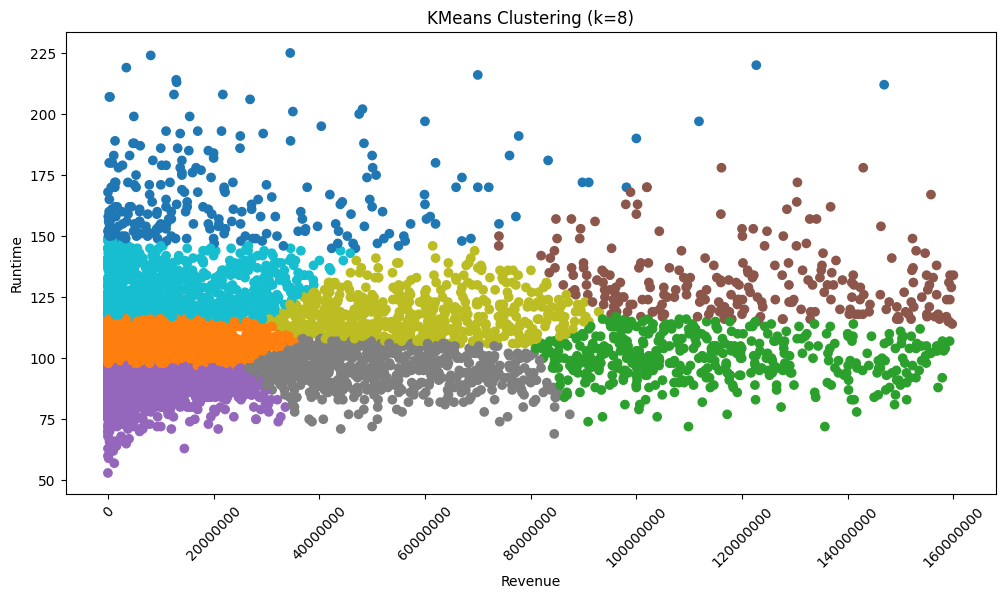

In [93]:
print('Filtering outliers using by visual analysis and recalculating Kmeans and replotting...')

filtered = metadata_kmeans[
    (metadata_kmeans['runtime'] >= 50) &
    (metadata_kmeans['runtime'] <= 240) &
    (metadata_kmeans['revenue'] <= 1.6e8)
]

print('Scaling Revenue and Runtime values...')

scaler = StandardScaler()
scaled_rr = scaler.fit_transform(filtered[['revenue', 'runtime']])



print(f'Use Elbow method to determine best k value between range of 2 to 10')

inerties = []
k_values = range(2, 16)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_rr)
    inerties.append(kmeans.inertia_)

plt.plot(k_values, inerties, marker='X')
plt.xlabel('K Value')
plt.ylabel('Inertia Value')
plt.title('Elbow Method')
plt.show()

print(f'\n\nUse KneeLocator from kneed library to determine elbow point.')
knee = KneeLocator(k_values, inerties, curve='convex', direction='decreasing')
print(f'The elbow is: {knee.elbow}')


k_values = [3, 5, 8]
print(f'choosing test cluster values of {k_values}')

print(f'Running KMeans clustering on revenue and runtime...')
for k in k_values:
    print(f'Running KMeans on Revenue and Runtime with K value of {k}...')
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_rr)
    filtered[f'cluster_{k}'] = kmeans.labels_

    print(f'Plotting outlier filtered result with K value of {k}...')
    plt.figure(figsize=(12, 6))
    plt.scatter(filtered['revenue'], filtered['runtime'], c = filtered[f'cluster_{k}'], cmap='tab10')
    plt.xlabel('Revenue')
    plt.ylabel('Runtime')
    plt.title(f'KMeans Clustering (k={k})')
    plt.ticklabel_format(style='plain', axis='x')
    plt.xticks(rotation=45)
    plt.show()



## Study 3

## Study 4

In [ ]:
userItemMatrix = ratings_smallDF.pivot(index='userId', columns='movieId', values='rating').fillna(0)
userItemArray = userItemMatrix.to_numpy()
userItemArrayValidation = userItemArray.copy()

In [ ]:
np.random.seed(17)

numToRemove = int(len(userItemArray) * 0.1)
removeIndices = np.random.choice(len(userItemArray), numToRemove, replace=False)
for idx in removeIndices:
    for i in range(len(userItemArrayValidation[idx])):
        userItemArrayValidation[idx][i] = 0

In [ ]:
def matrix_factorization(R, P, Q, K, steps=500, alpha=0.0004, beta=0.02):
    Q = Q.T
    error=[]
    for step in range(steps):
        for i in range(len(R)):
            for j in range(len(R[i])):
                if R[i][j] > 0:
                    eij = R[i][j] - np.dot(P[i,:],Q[:,j])
                    for k in range(K):
                        P[i][k] = P[i][k] + alpha * (2 * eij * Q[k][j] - beta * P[i][k])
                        Q[k][j] = Q[k][j] + alpha * (2 * eij * P[i][k] - beta * Q[k][j])
        eR = np.dot(P,Q)
        e = 0
        for i in range(len(R)):
            for j in range(len(R[i])):
                if R[i][j] > 0:
                    e = e + pow(R[i][j] - np.dot(P[i,:],Q[:,j]), 2)
                    for k in range(K):
                        e = e + (beta/2) * (pow(P[i][k],2) + pow(Q[k][j],2))
        error.append(e)
        if e < 0.001:
            break
    # for i in range(len(error)):
    #     print(error[i])    
    return P, Q.T

R = np.array(userItemArrayValidation)
N = len(R)
M = len(R[0])
K = 10
P = np.random.rand(N,K)
Q = np.random.rand(M,K)
nP, nQ = matrix_factorization(R, P, Q, K)
nR = np.dot(nP, nQ.T)

171537.57721497118
141995.14121080638
127861.69600039083
119304.24946871932
113396.62396276848
109002.60601750921
105575.96808242866
102813.18060938026
100528.86144782501
98602.20426977104
96950.64835735118
95515.65079971818
94254.44597834
93135.01241220415
92132.86584222502
91228.9438407439
90408.16923267354
89658.44991408098
88969.96726351578
88334.66011963476
87745.84415224417
87197.92676576563
86686.19056874907
86206.62682100643
85755.80582685905
85330.77499681884
84928.97787937301
84548.18926267036
84186.46271868283
83842.08787335652
83513.55534770206
83199.52779926301
82898.81585287493
82610.35797847137
82333.20357697534
82066.49869042309
81809.47387133012
81561.4338388056
81321.74862102464
81089.84594010869
80865.2046406421
80647.34899841933
80435.84377496381
80230.28990629896
80030.32073307855
79835.59869452628
79645.81242115775
79460.67417122694
79279.91756468039
79103.29557509974
78930.57874615099
78761.55360388203
78596.02124023033
78433.79604687663
78274.70458080636
78118.5

In [ ]:
np.random.seed(18)
user1 = np.random.randint(0, len(userItemArray))
while True:
    movie1 = np.random.randint(0, len(userItemArray[user1]))
    if userItemArray[user1][movie1] == 0:
        break
print(f"user {user1} is predicted to have rated movie {movie1}: {nR[user1][movie1]:.1f}")
top10_user1 = np.argsort(nR[user1])[::-1][:10]

print(f"Top 10 predicted ratings for user {user1}:")

for i in top10_user1:
    print(f"movie {i}: {nR[user1][i]:.1f}")

user 298 is predicted to have rated movie 2885: 3.4
Top 10 predicted ratings for user 298:
movie 8831: 6.4
movie 2724: 6.3
movie 8766: 6.1
movie 4979: 6.1
movie 3727: 6.1
movie 7968: 6.0
movie 4448: 6.0
movie 6591: 6.0
movie 8639: 6.0
movie 6490: 6.0


In [ ]:
np.random.seed(19)
user2 = np.random.randint(0, len(userItemArray))
while True:
    movie2 = np.random.randint(0, len(userItemArray[user2]))
    if userItemArray[user2][movie2] == 0:
        break
print(f"user {user2} is predicted to have rated movie {movie2}: {nR[user2][movie2]:.1f}")
top10_user2 = np.argsort(nR[user2])[::-1][:10]

print(f"Top 10 predicted ratings for user {user2}:")

for i in top10_user2:
    print(f"movie {i}: {nR[user2][i]:.1f}")

user 605 is predicted to have rated movie 757: 4.1
Top 10 predicted ratings for user 605:
movie 8831: 6.0
movie 5510: 5.9
movie 5759: 5.9
movie 5353: 5.8
movie 4296: 5.8
movie 7692: 5.7
movie 4979: 5.7
movie 7968: 5.7
movie 8766: 5.7
movie 7420: 5.6


In [ ]:
np.random.seed(20)
user3 = np.random.randint(0, len(userItemArray))
while True:
    movie3 = np.random.randint(0, len(userItemArray[user3]))
    if userItemArray[user3][movie3] == 0:
        break
print(f"user {user3} is predicted to have rated movie {movie3}: {nR[user3][movie3]:.1f}")
top10_user3 = np.argsort(nR[user3])[::-1][:10]

print(f"Top 10 predicted ratings for user {user3}:")

for i in top10_user3:
    print(f"movie {i}: {nR[user3][i]:.1f}")

user 355 is predicted to have rated movie 4367: 3.8
Top 10 predicted ratings for user 355:
movie 6591: 5.8
movie 7568: 5.6
movie 274: 5.4
movie 7946: 5.4
movie 6064: 5.4
movie 1244: 5.3
movie 8744: 5.3
movie 5353: 5.3
movie 2991: 5.3
movie 4979: 5.3


evaluate 1

In [ ]:
answer = 0
for idx in removeIndices:
    partialAnswer = 0
    yTrue = userItemArray[idx]
    yTruePart = []
    yPred = nR[idx]
    yPredPart = []
    for i in range(len(userItemArray[idx])):
        if userItemArray[idx][i] > 0:
            yTruePart.append(userItemArray[idx][i])
            yPredPart.append(nR[idx][i])
    partialAnswer = np.mean((np.array(yTruePart) - np.array(yPredPart))**2)
    answer += partialAnswer
answer /= len(removeIndices)
print(f"Mean Squared Error: {answer}")

Mean Squared Error: 0.39222938943663144


evaluate 2

In [ ]:
userItemBoolean = (userItemArray >= 4.0).astype(bool)

In [ ]:
precisionAt5 = []
for i in range(len(userItemBoolean)):
    top5Indices = np.argsort(nR[i])[::-1][:5]
    summation = 0
    for j in top5Indices:
        if userItemBoolean[i][j]:
            summation += 1
    precision = summation / 5.0
    precisionAt5.append(precision)
    print(f"User {i+1}: Precision@5 = {precision}")

User 1: Precision@5 = 0.0
User 2: Precision@5 = 0.0
User 3: Precision@5 = 0.0
User 4: Precision@5 = 0.0
User 5: Precision@5 = 0.0
User 6: Precision@5 = 0.0
User 7: Precision@5 = 0.0
User 8: Precision@5 = 0.0
User 9: Precision@5 = 0.0
User 10: Precision@5 = 0.0
User 11: Precision@5 = 0.0
User 12: Precision@5 = 0.0
User 13: Precision@5 = 0.0
User 14: Precision@5 = 0.0
User 15: Precision@5 = 0.6
User 16: Precision@5 = 0.0
User 17: Precision@5 = 0.2
User 18: Precision@5 = 0.0
User 19: Precision@5 = 0.0
User 20: Precision@5 = 0.0
User 21: Precision@5 = 0.0
User 22: Precision@5 = 0.0
User 23: Precision@5 = 0.0
User 24: Precision@5 = 0.0
User 25: Precision@5 = 0.0
User 26: Precision@5 = 0.0
User 27: Precision@5 = 0.0
User 28: Precision@5 = 0.0
User 29: Precision@5 = 0.0
User 30: Precision@5 = 0.0
User 31: Precision@5 = 0.0
User 32: Precision@5 = 0.0
User 33: Precision@5 = 0.0
User 34: Precision@5 = 0.0
User 35: Precision@5 = 0.0
User 36: Precision@5 = 0.0
User 37: Precision@5 = 0.0
User 38: P

In [ ]:
precisionAt10 = []
for i in range(len(userItemBoolean)):
    top10Indices = np.argsort(nR[i])[::-1][:10]
    summation = 0
    for j in top10Indices:
        if userItemBoolean[i][j]:
            summation += 1
    precision = summation / 10.0
    precisionAt10.append(precision)
    print(f"User {i+1}: Precision@10 = {precision}")

User 1: Precision@10 = 0.0
User 2: Precision@10 = 0.0
User 3: Precision@10 = 0.0
User 4: Precision@10 = 0.0
User 5: Precision@10 = 0.0
User 6: Precision@10 = 0.0
User 7: Precision@10 = 0.0
User 8: Precision@10 = 0.0
User 9: Precision@10 = 0.0
User 10: Precision@10 = 0.0
User 11: Precision@10 = 0.0
User 12: Precision@10 = 0.0
User 13: Precision@10 = 0.0
User 14: Precision@10 = 0.0
User 15: Precision@10 = 0.6
User 16: Precision@10 = 0.0
User 17: Precision@10 = 0.1
User 18: Precision@10 = 0.0
User 19: Precision@10 = 0.0
User 20: Precision@10 = 0.0
User 21: Precision@10 = 0.0
User 22: Precision@10 = 0.0
User 23: Precision@10 = 0.0
User 24: Precision@10 = 0.0
User 25: Precision@10 = 0.0
User 26: Precision@10 = 0.0
User 27: Precision@10 = 0.0
User 28: Precision@10 = 0.0
User 29: Precision@10 = 0.0
User 30: Precision@10 = 0.0
User 31: Precision@10 = 0.0
User 32: Precision@10 = 0.0
User 33: Precision@10 = 0.0
User 34: Precision@10 = 0.0
User 35: Precision@10 = 0.0
User 36: Precision@10 = 0.0
U

In [ ]:
mrrScores = []
for i in range(len(userItemBoolean)):
    rank = 0.0
    for j in range(len(userItemBoolean[i])):
        if userItemBoolean[i][j]:
            rank = 1.0 / (j + 1)
            break
    mrrScores.append(rank)

meanMrr = np.mean(mrrScores)
print(f"Mean Reciprocal Rank (MRR): {meanMrr}")

Mean Reciprocal Rank (MRR): 0.29001479034948874


## References

https://medium.com/data-science/recommendation-system-matrix-factorization-d61978660b4b
https://www.geeksforgeeks.org/python/python-mean-squared-error/
https://www.evidentlyai.com/ranking-metrics/precision-recall-at-k
https://www.geeksforgeeks.org/nlp/evaluation-metrics-for-retrieval-augmented-generation-rag-systems/